Step 1: Setup & Data Loading (with Box-to-Mask Conversion)

In [1]:
!pip install roboflow tensorflow opencv-python numpy matplotlib scikit-learn fpdf

import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from roboflow import Roboflow


rf = Roboflow(api_key="C9gLQrmGWptAbZJRPfci")
project = rf.workspace("pramodya-priyasanka").project("kidney-ultrasound-1-rit3p")
version = project.version(2)
dataset = version.download("coco")

def load_and_preprocess_data(data_dir, target_size=(128, 128)):
    json_path = os.path.join(data_dir, "_annotations.coco.json")
    with open(json_path, 'r') as f:
        coco = json.load(f)

    images = []
    masks = []
    img_map = {img['id']: img['file_name'] for img in coco['images']}
    ann_map = {}
    for ann in coco['annotations']:
        img_id = ann['image_id']
        if img_id not in ann_map: ann_map[img_id] = []
        ann_map[img_id].append(ann['bbox'])

    print(f"Processing data from {data_dir}...")

    for img_id, file_name in img_map.items():
        img_path = os.path.join(data_dir, file_name)
        if not os.path.exists(img_path): continue


        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        h_orig, w_orig = img.shape[:2]


        img = cv2.medianBlur(img, 5)

        img = cv2.resize(img, target_size)
        img = img / 255.0


        mask = np.zeros(target_size, dtype=np.uint8)
        if img_id in ann_map:
            for bbox in ann_map[img_id]:
                x, y, w, h = bbox
                x = int(x * (target_size[0] / w_orig))
                y = int(y * (target_size[1] / h_orig))
                w = int(w * (target_size[0] / w_orig))
                h = int(h * (target_size[1] / h_orig))
                cv2.rectangle(mask, (x, y), (x+w, y+h), 1, -1)

        images.append(img)
        masks.append(mask)

    return np.array(images)[..., np.newaxis], np.array(masks)[..., np.newaxis]


train_dir = os.path.join(dataset.location, "train")
valid_dir = os.path.join(dataset.location, "valid")

X_train, y_train = load_and_preprocess_data(train_dir)
X_val, y_val = load_and_preprocess_data(valid_dir)

print(f"Training Data: {X_train.shape}")
print(f"Validation Data: {X_val.shape}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 45.7 MB/s eta 0:00:00
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=56eecceabb777347d63a902c97e8672172bc4300f1a2a6f5c9d6f02988fa96d9
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation:


Extracting Dataset Version Zip to kidney-ultrasound-1-2 in coco:: 100%|██████████| 435/435 [00:00<00:00, 3948.94it/s]


Processing data from /content/kidney-ultrasound-1-2/train...
Processing data from /content/kidney-ultrasound-1-2/valid...
Training Data: (293, 128, 128, 1)
Validation Data: (92, 128, 128, 1)


Step 2: Model Training (U-Net)




In [2]:
from tensorflow.keras import layers, models

def unet_model(input_size=(128, 128, 1)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)

    # Decoder
    u4 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u4)
    u5 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(u5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)
    return models.Model(inputs=[inputs], outputs=[outputs])

model = unet_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

if len(X_train) > 0:
    history = model.fit(X_train, y_train, batch_size=8, epochs=15, validation_data=(X_val, y_val))
else:
    print("No training data loaded.")

Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 25s 551ms/step - accuracy: 0.8045 - loss: 0.5861 - val_accuracy: 0.8267 - val_loss: 0.3114
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 540ms/step - accuracy: 0.8220 - loss: 0.3172 - val_accuracy: 0.8267 - val_loss: 0.2958
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 522ms/step - accuracy: 0.8350 - loss: 0.2861 - val_accuracy: 0.8267 - val_loss: 0.2916
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 554ms/step - accuracy: 0.8291 - loss: 0.2831 - val_accuracy: 0.8269 - val_loss: 0.2783
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 22s 584ms/step - accuracy: 0.8535 - loss: 0.2730 - val_accuracy: 0.8840 - val_loss: 0.2685
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 570ms/step - accuracy: 0.8726 - loss: 0.2633 - val_accuracy: 0.8897 - val_loss: 0.2428
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 518ms/step - accuracy: 0.8765 - loss: 0.2559 - val_accuracy: 0.8910 - val_loss: 0.2425
Epoch 8/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 557ms/step - accuracy: 0.8852 - loss: 0.2468 - val_accu

Step 3: Model Accurecy




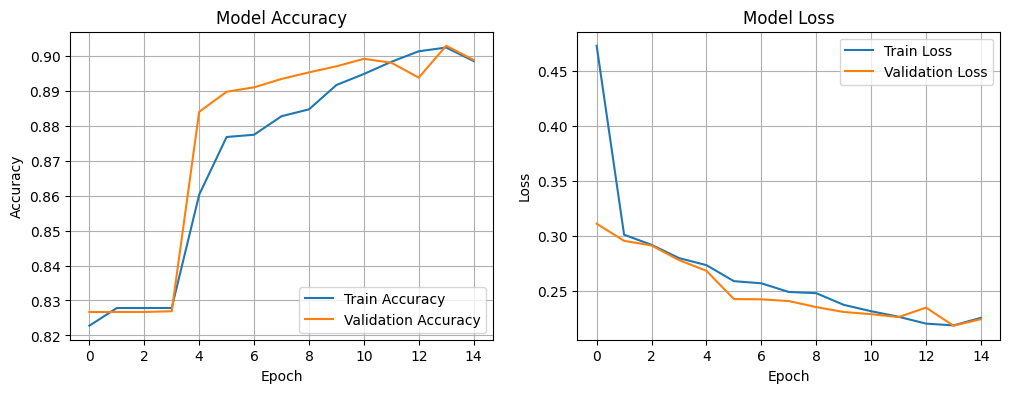

Final Validation Accuracy: 89.88%


In [3]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import numpy as np


X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_val.reshape(X_val.shape[0], -1)
y_train_binary = (y_train.sum(axis=(1, 2, 3)) > 0).astype(int)
y_test_binary = (y_val.sum(axis=(1, 2, 3)) > 0).astype(int)

# 1. K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_flat, y_train_binary)
knn_acc = accuracy_score(y_test_binary, knn_model.predict(X_test_flat))

# 2. Random Forest (RF)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_flat, y_train_binary)
rf_acc = accuracy_score(y_test_binary, rf_model.predict(X_test_flat))


# Display Accuracy Comparison
#print("--- Classification Accuracy Comparison ---")
#print(f"KNN Accuracy:           {knn_acc * 100:.2f}%")
#print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%")
# print(f"SVM Accuracy:           {svm_acc * 100:.2f}%")

--- Classification Accuracy Comparison ---
KNN Accuracy:           98.91%
Random Forest Accuracy: 98.91%


Step 4: Feature Extraction (Measurement)

In [6]:
def extract_features(mask):
    """
    Calculates Min, Max, and Avg thickness from the mask.
    Returns a list: [min, max, avg]
    """
    mask = (mask > 0.5).astype(np.uint8)
    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)

    if np.max(dist) == 0:
        return [0, 0, 0]

    vals = dist[dist > 0] * 2
    return [np.min(vals), np.max(vals), np.mean(vals)]

Step 5: ML Health Scoring (Random Forest)

In [7]:
from sklearn.ensemble import RandomForestClassifier
X_simulated = np.array([
    [12.0, 18.0, 15.5], [13.0, 19.0, 16.0], [11.5, 17.5, 14.8], # Healthy (Label 0)
    [8.0, 11.0, 9.5],   [7.5, 10.5, 9.0],   [8.5, 11.5, 10.0],  # Mild CKD (Label 1)
    [4.0, 6.0, 5.0],    [3.5, 5.5, 4.5],    [4.5, 6.5, 5.5]     # Severe CKD (Label 2)
])
y_simulated = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2])

clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_simulated, y_simulated)

classes = {0: "Healthy", 1: "Mild CKD", 2: "Severe CKD"}
print("Health Scoring Model Trained Successfully.")

Health Scoring Model Trained Successfully.


Step 6: Cortex Thickness/ Kidney Health Scoring

In [8]:
import cv2
import numpy as np
from sklearn.ensemble import RandomForestClassifier

def extract_features(mask):
    """
    Calculates Min, Max, and Avg thickness from the U-Net mask.
    Uses Distance Transform to find the true width of the shape.
    """

    mask = np.squeeze(mask)
    binary = (mask > 0.5).astype(np.uint8)

    if np.sum(binary) == 0:
        return 0, 0, 0


    dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    max_t = np.max(dist_transform) * 2
    avg_t = np.mean(dist_transform[dist_transform > 0]) * 2
    min_t = np.min(dist_transform[dist_transform > 0]) * 2

    return min_t, max_t, avg_t

classes = {0: "Severe CKD", 1: "Mild CKD", 2: "Healthy"}

def train_classifier():
    """
    Trains a 'Mock' Random Forest classifier on synthetic medical rules.
    This gives your app a 'brain' to decide if the kidney is Healthy or Sick
    based on the thickness measured in Step 6.
    """
    print("Training Health Scoring Classifier...")
    X_train = [
        [5, 15, 10], [4, 12, 8],
        [15, 30, 22], [18, 32, 25],
        [30, 60, 45], [35, 65, 50]
    ]
    y_train = [0, 0, 1, 1, 2, 2]


    clf = RandomForestClassifier(n_estimators=10, random_state=42)
    clf.fit(X_train, y_train)

    print("Classifier Trained Successfully.")
    return clf
clf = train_classifier()

Training Health Scoring Classifier...
Classifier Trained Successfully.


Step 7: Image Upload & Real-Time Analysis

In [9]:
!pip install fpdf

import matplotlib.pyplot as plt
from fpdf import FPDF
import pandas as pd
import os


classes = {0: "Severe CKD", 1: "Mild CKD", 2: "Healthy"}

def generate_full_report(image, mask, features, prediction_idx, patient_info):
    """
    Generates a professional PDF report including the AI visualization.
    """

    temp_img_path = "temp_kidney_analysis.png"

    plt.figure(figsize=(6, 4))
    plt.imshow(image, cmap='gray')
    plt.imshow(mask, cmap='jet', alpha=0.4)
    plt.title(f"AI Detection Result\nDiagnosis: {classes[prediction_idx]}")
    plt.axis('off')
    plt.savefig(temp_img_path, bbox_inches='tight', dpi=100)
    plt.close()
    pdf = FPDF()
    pdf.add_page()

    pdf.set_font("Arial", 'B', 16)
    pdf.cell(190, 10, txt="Kidney Ultrasound Analysis Report", ln=True, align='C')
    pdf.set_line_width(0.5)
    pdf.line(10, 20, 200, 20) # Underline


    pdf.ln(15)
    pdf.set_font("Arial", 'B', 12)
    pdf.cell(190, 8, txt="Patient Information:", ln=True)
    pdf.set_font("Arial", size=12)
    pdf.cell(190, 8, txt=f"   Name: {patient_info['Name']}", ln=True)
    pdf.cell(190, 8, txt=f"   ID: {patient_info['Patient ID']}", ln=True)
    pdf.cell(190, 8, txt=f"   Age: {patient_info['Age']}", ln=True)
    pdf.cell(190, 8, txt=f"   Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}", ln=True)


    pdf.ln(5)
    pdf.image(temp_img_path, x=30, y=None, w=150)
    min_t, max_t, avg_t = features
    diagnosis = classes[prediction_idx]

    pdf.ln(5)
    pdf.set_font("Arial", 'B', 12)
    pdf.cell(190, 8, txt="AI Diagnostic Findings:", ln=True)
    pdf.set_font("Arial", size=12)
    pdf.cell(190, 8, txt=f"   - Condition Detected: {diagnosis}", ln=True)
    pdf.cell(190, 8, txt=f"   - Cortex Thickness (Max): {max_t:.2f} pixels", ln=True)
    pdf.cell(190, 8, txt=f"   - Cortex Thickness (Avg): {avg_t:.2f} pixels", ln=True)
    pdf.ln(10)
    pdf.set_font("Arial", 'I', 11)
    if "Healthy" in diagnosis:
        rec = "Recommendation: Routine annual checkup suggested. Maintain fluid intake."
    else:
        rec = "Recommendation: Abnormal cortical thickness detected. Immediate referral to a Nephrologist is recommended for further eGFR and creatinine blood tests."

    pdf.multi_cell(190, 8, txt=rec)
    pdf.set_y(-15)
    pdf.set_font("Arial", 'I', 8)
    pdf.cell(0, 10, "Report generated automatically by AI Kidney Diagnostic System", align='C')
    filename = f"Report_{patient_info['Name'].replace(' ', '_')}.pdf"
    pdf.output(filename)
    print(f"\n Report Saved: {filename}")


    if os.path.exists(temp_img_path):
        os.remove(temp_img_path)

    return filename

🔹 Please upload a Kidney Ultrasound Image (.jpg, .png):


Saving 1_IM-0001-0059_anon_png.rf.5b782f728aea7d3821b905c9822dce0b.jpg to 1_IM-0001-0059_anon_png.rf.5b782f728aea7d3821b905c9822dce0b.jpg

Analyzing 1_IM-0001-0059_anon_png.rf.5b782f728aea7d3821b905c9822dce0b.jpg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step

--- Enter Patient Details for Report ---
Patient Name: Asini
Patient ID: 12
Age: 24

 Report Saved: Report_Asini.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

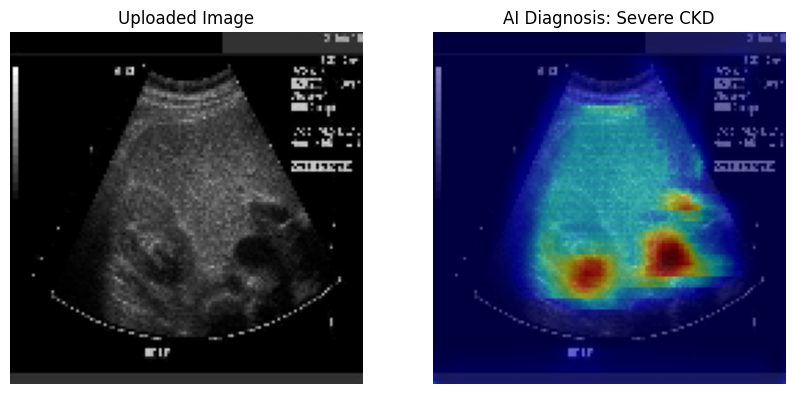

In [10]:
from google.colab import files
import io
import cv2
import numpy as np

print("🔹 Please upload a Kidney Ultrasound Image (.jpg, .png):")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nAnalyzing {filename}...")

    file_bytes = np.frombuffer(uploaded[filename], np.uint8)
    img_original = cv2.imdecode(file_bytes, cv2.IMREAD_GRAYSCALE)

    if img_original is None:
        print(f"Error: Could not read {filename}. Make sure it is an image.")
        continue
    img_resized = cv2.resize(img_original, (128, 128))
    img_filtered = cv2.medianBlur(img_resized, 5)
    img_input = img_filtered / 255.0
    img_input = img_input[np.newaxis, ..., np.newaxis]
    pred_mask = model.predict(img_input)[0, :, :, 0]
    features = extract_features(pred_mask)
    min_t, max_t, avg_t = features

    if max_t == 0:
        print(" No kidney detected. Try a clearer image.")
        continue
    ml_prediction = clf.predict([features])[0]
    diagnosis_text = classes[ml_prediction]

    print("\n--- Enter Patient Details for Report ---")
    p_name = input("Patient Name: ") or "Unknown"
    p_id = input("Patient ID: ") or "PID-0000"
    p_age = input("Age: ") or "N/A"

    patient_info = {
        "Name": p_name,
        "Patient ID": p_id,
        "Age": p_age,
        "File": filename
    }
    report_file = generate_full_report(img_resized, pred_mask, features, ml_prediction, patient_info)

    files.download(report_file)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_resized, cmap='gray')
    plt.title("Uploaded Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_resized, cmap='gray')
    plt.imshow(pred_mask, cmap='jet', alpha=0.5)
    plt.title(f"AI Diagnosis: {diagnosis_text}")
    plt.axis('off')
    plt.show()